## Customer Churn Prediction using Machine Learning

### Project Overview

Customer churn prediction is a supervised machine learning classification problem that aims to identify customers who are likely to discontinue a company's services. Early identification of potential churn enables organizations to implement targeted retention strategies, reduce customer attrition, and improve long-term business profitability.

This project develops an end-to-end machine learning pipeline using the IBM Telco Customer Churn dataset. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, model development, model evaluation, hyperparameter tuning, feature interpretation, and model persistence.

**Author:** Pratap N

**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost, Joblib

**Dataset:** IBM Telco Customer Churn Dataset


### Table of Contents

1. Import Libraries
2. Load the Dataset
3. Explore the Dataset
4. Data Cleaning and Preprocessing
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Train-Test Split
8. Feature Scaling
9. Model Building and Evaluation
10. Model Performance Comparison
11. Best Model Selection
12. Hyperparameter Tuning
13. Feature Interpretation
14. Save the Final Model
15. Project Summary
16. Conclusion


### Step 1: Import the Required Libraries and Load the Dataset

#### Objective

The objective of this step is to import the required library and load the customer churn dataset into a Pandas DataFrame. This prepares the dataset for exploration, preprocessing, and machine learning.


In [1]:
# Import the Pandas library
import pandas as pd

In [2]:
# Specify the file path
file_path = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [3]:
# Load the dataset
df = pd.read_csv(file_path)

### Step 2: Explore the Dataset

#### Objective

The objective of this step is to understand the structure, features, and overall characteristics of the dataset before performing data preprocessing and exploratory data analysis.


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Display the last five rows of the dataset
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
print(df.shape)

(7043, 21)


**Observation**

* The dataset contains **7,043 customer records** and **21 features**.


**Insight**

* The dataset size is adequate for building and evaluating a customer churn prediction model.


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observation**

* The dataset contains **7,043 records** and **21 features**.
* The dataset includes **18 categorical features**, **2 integer features**, and **1 floating-point feature**.
* All columns have **7,043 non-null values**.
* The `TotalCharges` feature is stored as the `object` data type.


**Insight**

* The `TotalCharges` feature should be converted to a numerical data type during data preprocessing to enable further analysis and model development.


In [9]:
# Generate descriptive statistics for the numerical features
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Observation**

* The descriptive statistics provide a summary of the numerical features, including the count, mean, standard deviation, minimum, maximum, and quartile values.
* The `tenure` feature ranges from **0** to **72** months.
* The `MonthlyCharges` feature ranges from approximately **18.25** to **118.75**.


In [10]:
# Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Observation**

* No missing values were found in any of the features.


**Insight**

* Since the dataset does not contain missing values, no missing value treatment is required during data preprocessing.


### Step 3: Exploratory Data Analysis (EDA)

#### Objective

The objective of this step is to explore the dataset using visualizations and descriptive analysis. This helps identify patterns, relationships, trends, and potential factors that influence customer churn.


In [11]:
# Import the required libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

In [12]:
# Display the distribution of the target variable
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

**Observation**

* The dataset contains **5,174** customers who did not churn and **1,869** customers who churned.
* The target variable is imbalanced, with a higher proportion of customers who did not churn.


**Insight**

* The class imbalance should be considered during model development, as it may affect the performance of machine learning algorithms. Appropriate evaluation metrics and imbalance handling techniques may be required.


### Step 3.1: Distribution of Customer Churn

#### Objective

The objective of this step is to examine the distribution of the target variable (`Churn`). Understanding the class distribution helps identify whether the dataset is balanced or imbalanced before building machine learning models.


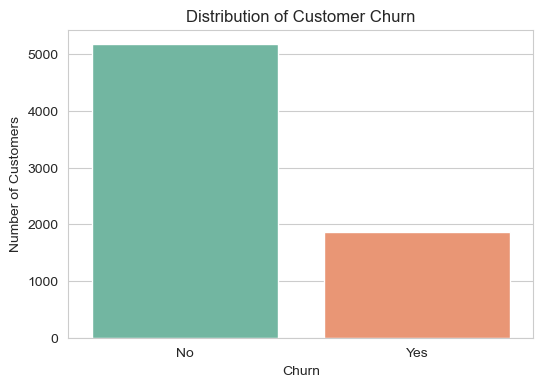

In [13]:
# Create the figure
plt.figure(figsize=(6, 4))

# Plot the distribution of the target variable
sns.countplot(
    x="Churn",
    hue="Churn",
    data=df,
    palette="Set2",
    legend=False
)

# Add title and labels
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Save the figure
plt.savefig("../images/churn_distribution.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

**Observation**

* The bar chart visually confirms that the number of customers who did not churn is considerably higher than the number of customers who churned.


**Insight**

* The imbalance in the target variable should be considered during model training to ensure reliable and unbiased predictions.


### Step 3.2: Gender vs Customer Churn

#### Objective

The objective of this step is to examine the relationship between customer gender and churn. This analysis helps determine whether gender has a noticeable influence on customer churn.


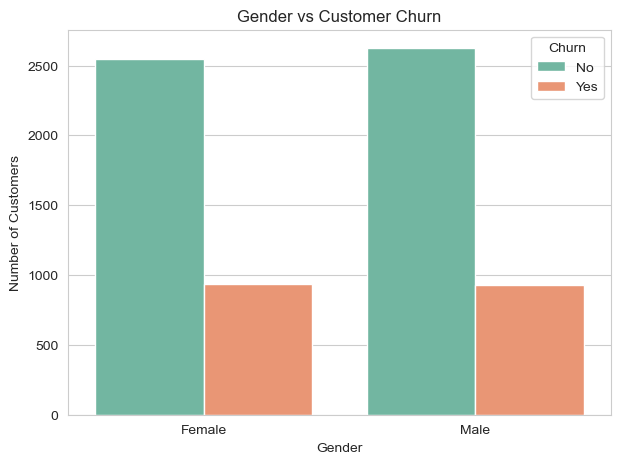

In [14]:
# Create the figure
plt.figure(figsize=(7, 5))

# Plot Gender vs Churn
sns.countplot(
    x="gender",
    hue="Churn",
    data=df,
    palette="Set2"
)

# Add title and labels
plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Add legend
plt.legend(title="Churn")

# Save the figure
plt.savefig("../images/gender_vs_churn.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

**Observation**

* The distribution of customer churn is similar for both male and female customers.
* No significant difference in churn behavior is observed between the two gender groups.

**Insight**

* Gender does not appear to be a strong predictor of customer churn and is unlikely to have a substantial impact on the prediction model.


### Step 3.3: Senior Citizen vs Customer Churn

#### Objective

The objective of this step is to examine the relationship between senior citizen status and customer churn. This analysis helps determine whether senior citizens have different churn patterns compared to non-senior citizens.


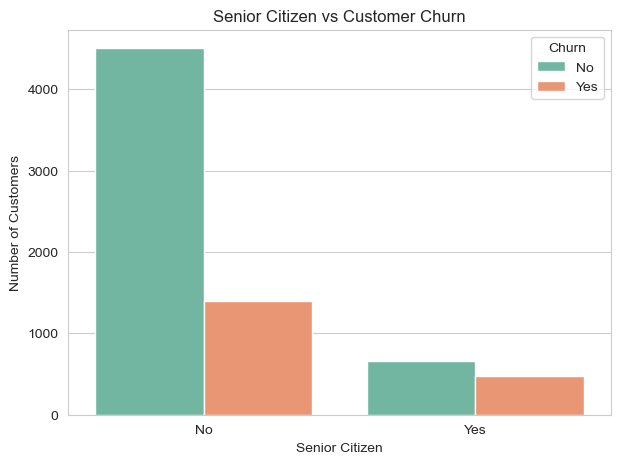

In [15]:
# Create the figure
plt.figure(figsize=(7, 5))

# Plot Senior Citizen vs Churn
sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df,
    palette="Set2"
)

# Add title and labels
plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

# Improve x-axis labels
plt.xticks([0, 1], ["No", "Yes"])

# Add legend
plt.legend(title="Churn")

# Save the figure
plt.savefig("../images/senior_citizen_vs_churn.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

**Observation**

* Senior citizens exhibit a higher proportion of customer churn compared to non-senior citizens.
* Although senior citizens represent a smaller portion of the customer base, they are more likely to discontinue the service.

**Insight**

* Senior citizen status appears to be an important factor associated with customer churn. Customer retention strategies tailored to senior citizens may help reduce churn in this segment.


### Step 3.4: Contract Type vs Customer Churn

#### Objective

The objective of this step is to examine the relationship between contract type and customer churn. This analysis helps determine whether the duration of a customer's contract influences their likelihood of churning.


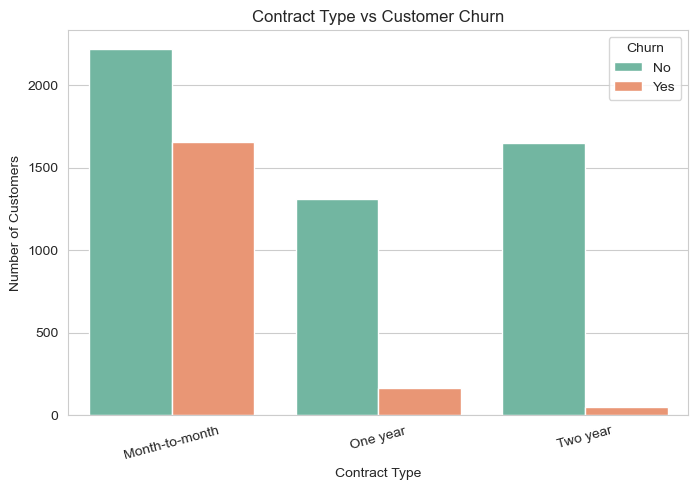

In [16]:
# Create the figure
plt.figure(figsize=(8, 5))

# Plot Contract Type vs Churn
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df,
    palette="Set2"
)

# Add title and labels
plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

# Rotate x-axis labels
plt.xticks(rotation=15)

# Add legend
plt.legend(title="Churn")

# Save the figure
plt.savefig("../images/contract_vs_churn.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

**Observation**

* Customers with **Month-to-month** contracts exhibit the highest number of churn cases.
* Customers with **One year** and **Two year** contracts have considerably lower churn rates.
* The number of retained customers increases as the contract duration becomes longer.

**Insight**

* Contract type is a strong indicator of customer churn. Customers with long-term contracts are more likely to remain with the company, while customers on month-to-month contracts are at a higher risk of churning. Encouraging customers to adopt longer-term contracts may help improve customer retention.


### Step 3.5: Internet Service vs Customer Churn

#### Objective

The objective of this step is to examine the relationship between internet service type and customer churn. This analysis helps identify whether customers with different internet service types exhibit different churn patterns.


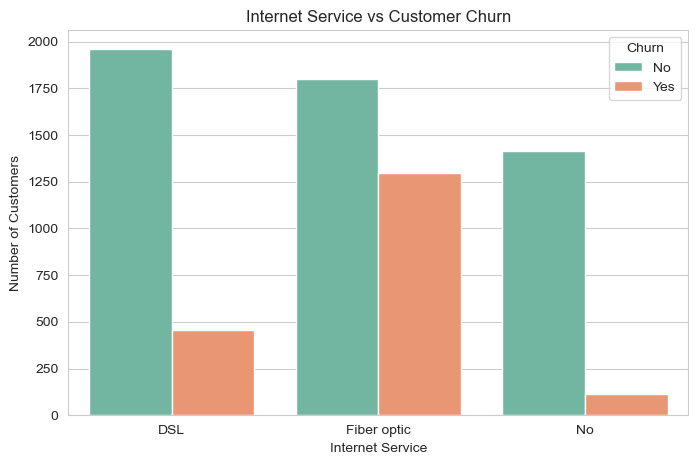

In [17]:
# Create the figure
plt.figure(figsize=(8, 5))

# Plot Internet Service vs Churn
sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df,
    palette="Set2"
)

# Add title and labels
plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

# Add legend
plt.legend(title="Churn")

# Save the figure
plt.savefig("../images/internet_service_vs_churn.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

**Observation**

* Customers using **Fiber optic** internet service exhibit the highest number of churn cases.
* Customers using **DSL** have a comparatively lower number of churn cases.
* Customers with **No internet service** show the lowest level of customer churn.

**Insight**

* Internet service type appears to influence customer churn. Customers using Fiber optic service are more likely to churn, suggesting that service quality, pricing, or customer expectations for this group may require further investigation to improve customer retention.


### Step 3.6: Payment Method vs Customer Churn

#### Objective

The objective of this step is to examine the relationship between payment method and customer churn. This analysis helps determine whether customer payment preferences are associated with different churn patterns.


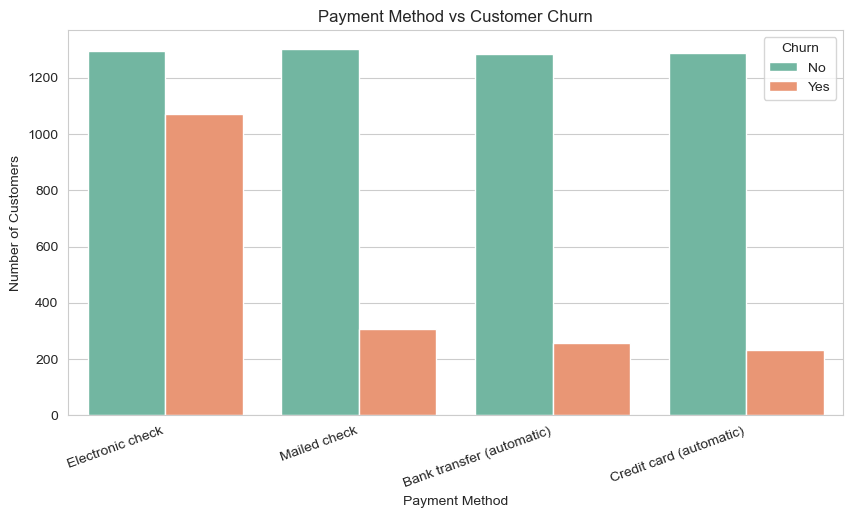

In [18]:
# Create the figure
plt.figure(figsize=(10, 5))

# Plot Payment Method vs Churn
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df,
    palette="Set2"
)

# Add title and labels
plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

# Rotate x-axis labels for better readability
plt.xticks(rotation=20, ha="right")

# Add legend
plt.legend(title="Churn")

# Save the figure
plt.savefig("../images/payment_method_vs_churn.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

**Observation**

* Customers using **Electronic check** exhibit the highest number of churn cases.
* Customers using **Bank transfer (automatic)** and **Credit card (automatic)** generally show lower churn compared to customers using Electronic check.
* Customers using **Mailed check** show a moderate level of customer churn.

**Insight**

* Payment method appears to be associated with customer churn. Customers using **Electronic check** are more likely to churn, indicating that promoting automatic payment methods may help improve customer retention and reduce churn.


### Step 3.7: Customer Tenure by Churn

#### Objective

The objective of this step is to analyze the relationship between customer tenure and churn. This analysis helps determine whether the length of time a customer has stayed with the company influences their likelihood of churning.


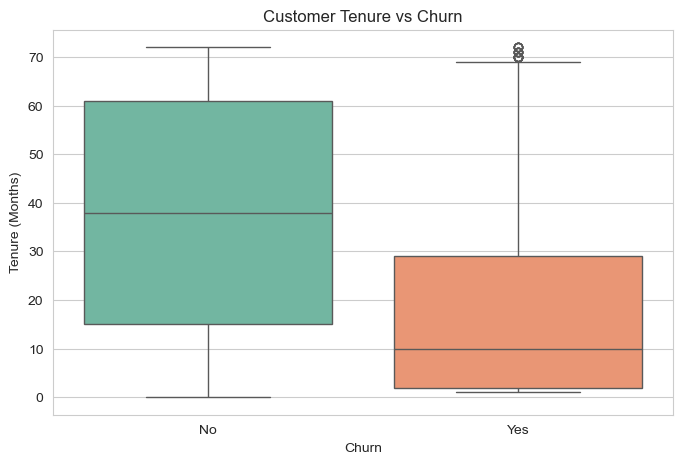

In [19]:
# Create the figure
plt.figure(figsize=(8, 5))

# Plot Tenure vs Churn
sns.boxplot(
    x="Churn",
    y="tenure",
    hue="Churn",
    data=df,
    palette="Set2",
    legend=False
)

# Add title and labels
plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

# Save the figure
plt.savefig("../images/tenure_vs_churn.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

**Observation**

* Customers who churned generally have shorter tenures than customers who remained with the company.
* Customers with longer tenures are more likely to continue using the service.
* The distribution indicates a clear difference in tenure between churned and retained customers.

**Insight**

* Customer tenure is a strong indicator of customer churn. Newer customers are at a higher risk of churning, suggesting that improving customer engagement and support during the early months may help increase customer retention.


### Step 3.8: Monthly Charges by Customer Churn

#### Objective

The objective of this step is to examine the relationship between monthly charges and customer churn. This analysis helps determine whether customers with higher monthly charges are more likely to churn.


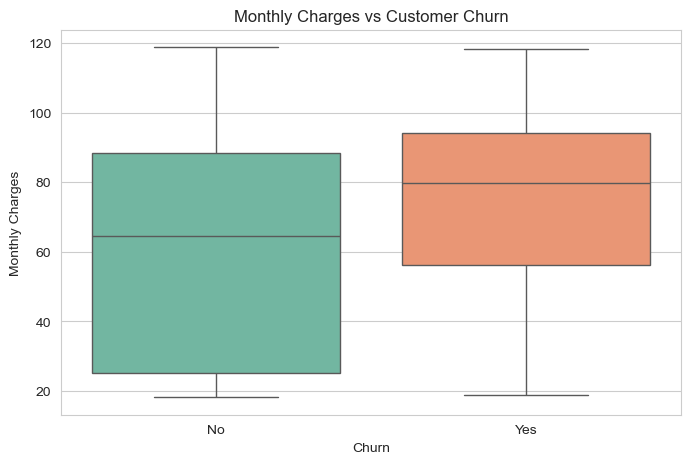

In [20]:
# Create the figure
plt.figure(figsize=(8, 5))

# Plot Monthly Charges vs Churn
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    data=df,
    palette="Set2",
    legend=False
)

# Add title and labels
plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

# Save the figure
plt.savefig("../images/monthly_charges_vs_churn.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

**Observation**

* Customers who churned generally have higher monthly charges than customers who remained with the company.
* The distribution of monthly charges for churned customers is shifted toward higher values.

**Insight**

* Higher monthly charges appear to be associated with an increased likelihood of customer churn. Reviewing pricing strategies or providing additional value to customers with higher monthly charges may help improve customer retention.


### Step 3.9: Correlation Heatmap

#### Objective

The objective of this step is to examine the relationships among the numerical features in the dataset. A correlation heatmap helps identify the strength and direction of the linear relationship between numerical variables.


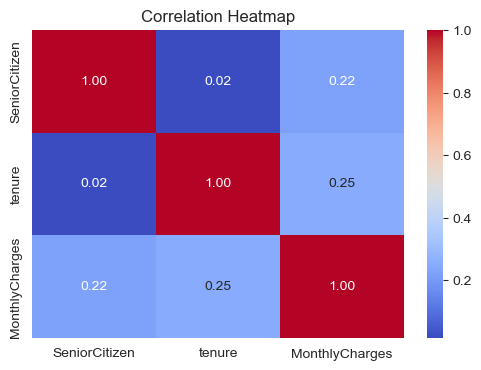

In [21]:
# Compute the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Create the figure
plt.figure(figsize=(6, 4))

# Plot the correlation heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Add title
plt.title("Correlation Heatmap")

# Save the figure
plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

**Observation**

* The heatmap displays the correlation among the numerical features in the dataset.
* No pair of numerical features exhibits a strong positive or negative correlation.
* The numerical features appear to be relatively independent of one another.

**Insight**

* The absence of strong correlations suggests that multicollinearity is unlikely to be a concern among the numerical features. Each feature is expected to contribute unique information to the machine learning model.


### Step 4: Data Preprocessing

#### Objective

The objective of this step is to prepare the dataset for machine learning by correcting data types, handling missing values, and transforming the data into a suitable format for model development.


### Step 4.1: Convert the `TotalCharges` Feature to a Numerical Data Type

#### Objective

The objective of this step is to convert the `TotalCharges` feature from the `object` data type to a numerical data type so that it can be used for analysis and machine learning.


In [22]:
# Convert the TotalCharges feature to a numerical data type
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [23]:
# Verify the updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observation**

* The `TotalCharges` feature has been successfully converted from the `object` data type to the `float64` data type.
* During the conversion, **11 records** were converted to missing values (`NaN`).

**Insight**

* Converting `TotalCharges` to a numerical data type makes it suitable for statistical analysis and machine learning. The resulting missing values should be handled before model development to ensure data quality.


### Step 4.2: Check for Missing Values

#### Objective

The objective of this step is to identify missing values in the dataset after converting the `TotalCharges` feature to a numerical data type.


In [24]:
# Check for missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

**Observation**

* The `TotalCharges` feature contains **11 missing values**, while all other features contain complete records.
* These missing values were identified after converting the `TotalCharges` feature to a numerical data type.

**Insight**

* Since only **11 out of 7,043 records** (approximately **0.16%**) contain missing values, removing these records is an appropriate preprocessing strategy. This approach preserves the integrity of the dataset while ensuring complete data for machine learning.


### 4.3 Handle Missing Values

#### Objective

The objective of this step is to remove records containing missing values to ensure the dataset is complete and suitable for machine learning.


In [25]:
# Remove records with missing values
df = df.dropna()

In [26]:
# Verify the dataset after removing missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Observation**

* All missing values have been successfully removed from the dataset.
* The dataset no longer contains any missing values across all features.

**Insight**

* A complete dataset improves data quality and ensures that machine learning algorithms can be trained without errors caused by missing values.


In [27]:
# Check the updated shape of the dataset
df.shape

(7032, 21)

**Observation**

* The dataset now contains **7,032 records** and **21 features**.
* A total of **11 records** were removed during data preprocessing.

**Insight**

* Removing only **11 out of 7,043 records** (approximately **0.16%** of the dataset) has a negligible impact on the dataset while ensuring complete and reliable data for model development.


### Step 5: Feature Engineering

#### Objective

The objective of this step is to prepare the dataset for machine learning by removing unnecessary features and converting categorical variables into numerical representations that can be processed by machine learning algorithms.


### 5.1 Remove the `customerID` Feature

#### Objective

The objective of this step is to remove the `customerID` feature because it is a unique identifier and does not provide useful information for predicting customer churn.


In [28]:
# Remove the customerID feature
df.drop("customerID", axis=1, inplace=True)

In [29]:
# Verify the updated dataset
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Observation**

* The `customerID` feature has been successfully removed from the dataset.
* The dataset now contains only customer attributes and the target variable relevant for analysis and prediction.

**Insight**

* Since `customerID` is a unique identifier, it does not contribute to predicting customer churn. Removing it helps improve the quality of the feature set by eliminating non-informative data.


### 5.2 Encode the Target Variable (`Churn`)

#### Objective

The objective of this step is to convert the target variable into a numerical format so that it can be used by machine learning algorithms for binary classification.


In [30]:
# Display the unique values of the target variable
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [31]:
# Encode the target variable
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [32]:
# Verify the encoding
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

**Observation**

* The target variable has been successfully encoded into numerical values.
* Customers who did not churn are represented by **0**, while customers who churned are represented by **1**.

**Insight**

* Encoding the target variable into numerical values enables machine learning algorithms to perform binary classification and predict customer churn effectively.


### 5.3 Encode the Categorical Features

#### Objective

The objective of this step is to convert all categorical input features into numerical representations using One-Hot Encoding. This transformation enables machine learning algorithms to process categorical data effectively without introducing any ordinal relationship between categories.


In [33]:
# Display the categorical features
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [34]:
# Apply One-Hot Encoding to the categorical features
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [35]:
# Display the first five rows of the encoded dataset
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [36]:
# Check the shape of the encoded dataset
df.shape

(7032, 31)

**Observation**

* All categorical features have been successfully converted into numerical features using One-Hot Encoding.
* The number of features has increased as each categorical feature has been transformed into one or more binary indicator variables.
* The dataset is now completely numerical and ready for machine learning.

**Insight**

* One-Hot Encoding preserves the information contained in categorical variables without introducing an artificial order among categories. This ensures that machine learning algorithms can learn meaningful patterns from the data effectively.


### 5.4 Verify the Encoded Dataset

#### Objective

The objective of this step is to verify that the dataset has been successfully transformed into a fully numerical format and is ready for machine learning.


In [37]:
# Display information about the encoded dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   int64  
 6   Partner_Yes                            7032 non-null   int64  
 7   Dependents_Yes                         7032 non-null   int64  
 8   PhoneService_Yes                       7032 non-null   int64  
 9   MultipleLines_No phone service         7032 non-null   int64  
 10  MultipleLines_Yes                      7032 non-null   int64  
 11  InternetS

**Observation**

* The dataset has been successfully transformed into a fully numerical format.
* All categorical features have been encoded, and no `object` data type remains.
* The dataset contains no missing values and is ready for machine learning.

**Insight**

* The successful completion of feature engineering ensures that the dataset is compatible with machine learning algorithms. The data is now ready for feature selection, train-test splitting, feature scaling, and model development.


### Step 6: Feature Selection

#### Objective

The objective of this step is to separate the input features (`X`) from the target variable (`y`). This prepares the dataset for training and evaluating machine learning models.


In [38]:
# Separate the input features and the target variable
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [39]:
# Display the shape of the input features and target variable
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (7032, 30)
Shape of y: (7032,)


**Observation**

* The dataset has been successfully divided into input features (`X`) and the target variable (`y`).
* The input feature matrix contains all predictor variables, while the target variable contains the customer churn labels.

**Insight**

* Separating the features and target variable is an essential step before splitting the dataset into training and testing sets. This ensures that the machine learning model learns from the predictor variables while using the target variable for supervised learning.


### Step 7: Train-Test Split

#### Objective

The objective of this step is to divide the dataset into training and testing sets. The training set is used to train the machine learning models, while the testing set is used to evaluate their performance on unseen data.


In [40]:
# Import the required library
from sklearn.model_selection import train_test_split

In [41]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [42]:
# Display the shape of the training and testing datasets
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)


**Observation**

* The dataset has been successfully split into training and testing sets using an 80:20 ratio.
* Stratified sampling was applied to preserve the class distribution of the target variable in both datasets.

**Insight**

* Splitting the dataset before model training enables an unbiased evaluation of model performance on unseen data. Using stratified sampling improves the reliability of performance metrics for an imbalanced classification problem.


### Step 8: Feature Scaling

#### Objective

The objective of this step is to standardize the input features so that they have a mean of 0 and a standard deviation of 1. Feature scaling improves the performance of distance-based and gradient-based machine learning algorithms.


In [43]:
# Import the StandardScaler
from sklearn.preprocessing import StandardScaler

In [44]:
# Create an instance of StandardScaler
scaler = StandardScaler()

In [45]:
# Fit the scaler on the training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
# Display the shape of the scaled datasets
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (5625, 30)
X_test_scaled : (1407, 30)


**Observation**

* The training and testing datasets have been successfully standardized using `StandardScaler`.
* The scaled datasets retain the same number of records and features as the original datasets.

**Insight**

* Standardizing the features ensures that variables measured on different scales contribute equally during model training. This is particularly beneficial for algorithms such as Logistic Regression, Support Vector Machine (SVM), and K-Nearest Neighbors (KNN), resulting in improved model performance and faster convergence.


### Step 9: Model Building and Evaluation

#### Objective

The objective of this step is to train and evaluate multiple machine learning classification models for predicting customer churn. The performance of each model will be compared to identify the most suitable model for the dataset.


### 9.1 Logistic Regression

#### Objective

The objective of this step is to train a Logistic Regression model as a baseline classifier and evaluate its performance in predicting customer churn.


In [47]:
# Import the Logistic Regression model
from sklearn.linear_model import LogisticRegression

In [48]:
# Create the Logistic Regression model
log_reg = LogisticRegression(random_state=42)

In [49]:
# Train the model
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [50]:
# Make predictions on the test dataset
y_pred_lr = log_reg.predict(X_test_scaled)

In [51]:
# Display the first 10 predictions
y_pred_lr[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [52]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [53]:
# Calculate the evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")

Accuracy : 0.8038
Precision: 0.6476
Recall   : 0.5749
F1-Score : 0.6091


In [54]:
# Display the classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



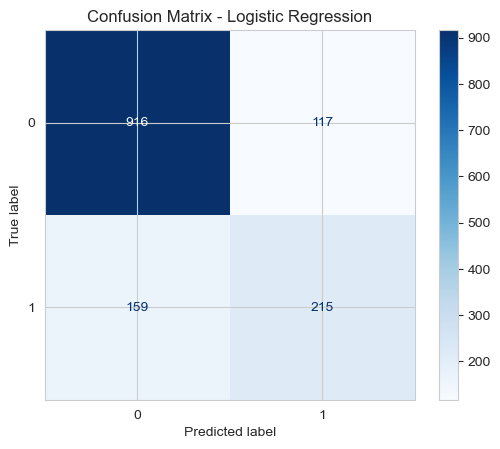

In [55]:
# Display the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.savefig(
    "../images/confusion_matrix_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation**

* The Logistic Regression model achieved an **accuracy of 80.38%** on the test dataset.
* The model obtained a **precision of 64.76%**, indicating that approximately two-thirds of the customers predicted to churn actually churned.
* The **recall of 57.49%** shows that the model correctly identified more than half of the customers who churned.
* The model achieved an **F1-score of 60.91%**, providing a balanced measure of precision and recall.
* The classification report indicates that the model performs better at predicting customers who did not churn than customers who churned.

**Insight**

* Logistic Regression provides a strong baseline model with good overall performance. However, its relatively lower recall suggests that a considerable number of actual churn cases are still missed. Since identifying customers at risk of churning is a key business objective, improving recall should be a priority. More advanced models such as Random Forest, XGBoost, or tuned ensemble methods may provide better churn detection while maintaining competitive overall performance.


### 9.2 Decision Tree Classifier

#### Objective

The objective of this step is to train a Decision Tree Classifier and evaluate its performance in predicting customer churn. Decision Trees are interpretable models that learn decision rules from the training data and can capture non-linear relationships.


In [56]:
# Import the Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

In [57]:
# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)

In [58]:
# Train the model
decision_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [59]:
# Make predictions on the test dataset
y_pred_dt = decision_tree.predict(X_test)

In [60]:
# Display the first 10 predictions
y_pred_dt[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 1, 0])

In [61]:
# Calculate the evaluation metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-Score : {dt_f1:.4f}")

Accuracy : 0.7186
Precision: 0.4701
Recall   : 0.4626
F1-Score : 0.4663


In [62]:
# Display the classification report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.46      0.47       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407



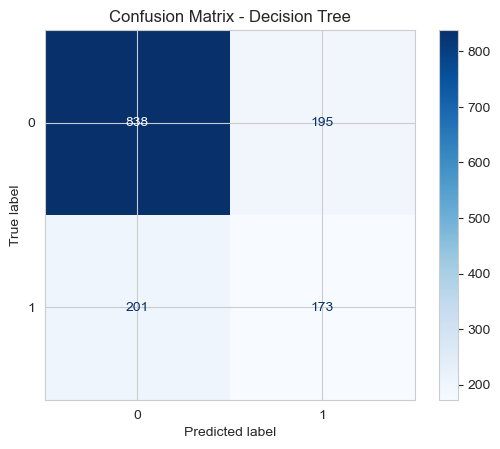

In [63]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Blues"
)

plt.title("Confusion Matrix - Decision Tree")

plt.savefig(
    "../images/confusion_matrix_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [64]:
# Create a list to store model evaluation results
results = []

# Add Logistic Regression results
results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1-Score": lr_f1
})

# Add Decision Tree results
results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1-Score": dt_f1
})

**Observation**

* The Decision Tree Classifier achieved an **accuracy of 71.86%** on the test dataset.
* The model obtained a **precision of 47.01%**, **recall of 46.26%**, and an **F1-score of 46.63%**.
* Compared to Logistic Regression, the Decision Tree Classifier produced lower values for all evaluation metrics.
* The classification report indicates that the model performs better at predicting customers who did not churn than customers who churned.

**Insight**

* The default Decision Tree Classifier does not generalize as effectively as Logistic Regression for this dataset. Its lower precision, recall, and F1-score suggest that it struggles to identify churned customers accurately. Hyperparameter tuning may improve its performance, but based on the current results, Logistic Regression remains the stronger baseline model.


### 9.3 Random Forest Classifier

#### Objective

The objective of this step is to train a Random Forest Classifier and evaluate its performance in predicting customer churn. Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.


In [65]:
# Import the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [66]:
# Create the Random Forest model
random_forest = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

In [67]:
# Train the model
random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [68]:
# Make predictions on the test dataset
y_pred_rf = random_forest.predict(X_test)

In [69]:
# Display the first 10 predictions
y_pred_rf[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [70]:
# Calculate the evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")

Accuracy : 0.7896
Precision: 0.6258
Recall   : 0.5187
F1-Score : 0.5673


In [71]:
# Display the classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



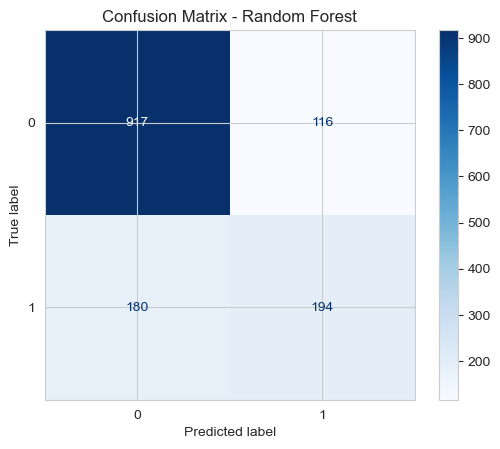

In [72]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")

plt.savefig(
    "../images/confusion_matrix_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
# Store the Random Forest evaluation results
results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1
})

**Observation**

* The Random Forest Classifier achieved an **accuracy of 78.96%** on the test dataset.
* The model obtained a **precision of 62.58%**, **recall of 51.87%**, and an **F1-score of 56.73%**.
* Compared to Logistic Regression, the Random Forest Classifier achieved slightly lower accuracy, recall, and F1-score.
* The classification report indicates that the model predicts customers who did not churn more accurately than customers who churned.

**Insight**

* The default Random Forest Classifier demonstrates strong predictive performance but does not outperform Logistic Regression on this dataset. Its lower recall indicates that it misses more actual churn cases. Hyperparameter tuning may improve its performance, making it a strong candidate for further optimization.


In [74]:
# Store the Random Forest evaluation results
results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-Score": rf_f1
})

### 9.4 K-Nearest Neighbors (KNN) Classifier

#### Objective

The objective of this step is to train a K-Nearest Neighbors (KNN) Classifier and evaluate its performance in predicting customer churn. KNN classifies a customer based on the majority class of its nearest neighbors in the feature space.


In [75]:
# Import the K-Nearest Neighbors Classifier
from sklearn.neighbors import KNeighborsClassifier

In [76]:
# Create the KNN model
knn = KNeighborsClassifier(n_neighbors=5)

In [77]:
# Train the model
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [78]:
# Make predictions on the test dataset
y_pred_knn = knn.predict(X_test_scaled)

In [79]:
# Display the first 10 predictions
y_pred_knn[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 1, 0])

In [80]:
# Calculate the evaluation metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1-Score : {knn_f1:.4f}")

Accuracy : 0.7541
Precision: 0.5374
Recall   : 0.5374
F1-Score : 0.5374


In [81]:
# Display the classification report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1033
           1       0.54      0.54      0.54       374

    accuracy                           0.75      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.75      0.75      0.75      1407



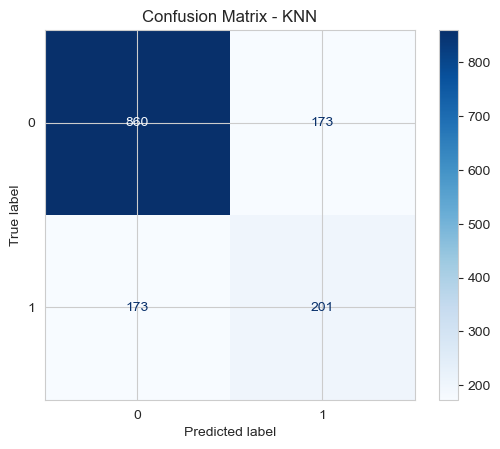

In [82]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    cmap="Blues"
)

plt.title("Confusion Matrix - KNN")

plt.savefig(
    "../images/confusion_matrix_knn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
# Store the KNN evaluation results
results.append({
    "Model": "K-Nearest Neighbors",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1-Score": knn_f1
})

**Observation**

* The K-Nearest Neighbors (KNN) Classifier achieved an **accuracy of 75.41%** on the test dataset.
* The model obtained a **precision of 53.74%**, **recall of 53.74%**, and an **F1-score of 53.74%**.
* Compared to Logistic Regression and Random Forest, the KNN Classifier achieved lower performance across most evaluation metrics.
* The classification report indicates that the model predicts customers who did not churn more accurately than customers who churned.

**Insight**

* The KNN Classifier provides moderate predictive performance but does not outperform Logistic Regression or Random Forest for this dataset. Although feature scaling improves KNN performance, its overall ability to identify churned customers remains limited. Further tuning of the number of neighbors (`n_neighbors`) may improve performance, but it is unlikely to surpass the best-performing models on this dataset.


### 9.5 Support Vector Machine (SVM)

#### Objective

The objective of this step is to train a Support Vector Machine (SVM) classifier and evaluate its performance in predicting customer churn. SVM identifies the optimal decision boundary that best separates customers who churn from those who do not.


In [84]:
# Import the Support Vector Machine classifier
from sklearn.svm import SVC

In [85]:
# Create the SVM model
svm = SVC(
    kernel="rbf",
    random_state=42
)

In [86]:
# Train the model
svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [87]:
# Make predictions on the test dataset
y_pred_svm = svm.predict(X_test_scaled)

In [88]:
# Display the first 10 predictions
y_pred_svm[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [89]:
# Calculate the evaluation metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-Score : {svm_f1:.4f}")

Accuracy : 0.7868
Precision: 0.6259
Recall   : 0.4920
F1-Score : 0.5509


In [90]:
# Display the classification report
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



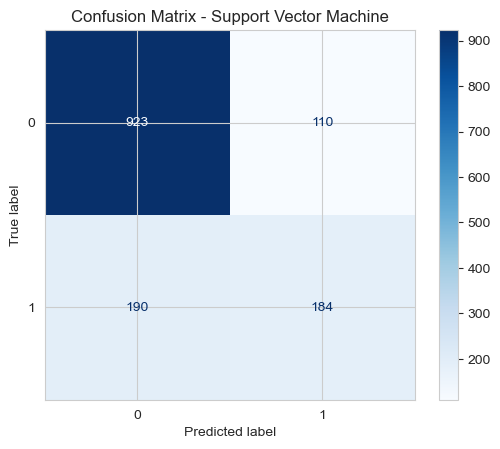

In [91]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    cmap="Blues"
)

plt.title("Confusion Matrix - Support Vector Machine")

plt.savefig(
    "../images/confusion_matrix_svm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
# Store the SVM evaluation results
results.append({
    "Model": "Support Vector Machine",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1-Score": svm_f1
})

### 9.6 Naive Bayes

#### Objective

The objective of this step is to train a Gaussian Naive Bayes classifier and evaluate its performance in predicting customer churn. Naive Bayes is a probabilistic classification algorithm that assumes the features are conditionally independent given the target class.


In [93]:
# Import the Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

In [94]:
# Create the Gaussian Naive Bayes model
naive_bayes = GaussianNB()

In [95]:
# Train the model
naive_bayes.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [96]:
# Make predictions on the test dataset
y_pred_nb = naive_bayes.predict(X_test_scaled)

In [97]:
# Display the first 10 predictions
y_pred_nb[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 1, 0])

In [98]:
# Calculate the evaluation metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1-Score : {nb_f1:.4f}")

Accuracy : 0.6446
Precision: 0.4184
Recall   : 0.8636
F1-Score : 0.5637


In [99]:
# Display the classification report
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.92      0.57      0.70      1033
           1       0.42      0.86      0.56       374

    accuracy                           0.64      1407
   macro avg       0.67      0.71      0.63      1407
weighted avg       0.79      0.64      0.66      1407



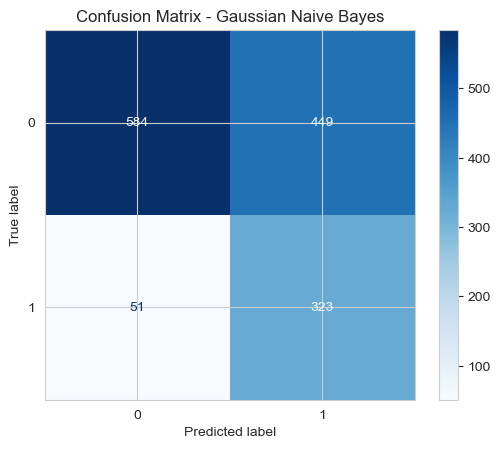

In [100]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    cmap="Blues"
)

plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.savefig(
    "../images/confusion_matrix_gaussian_naive_bayes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [101]:
# Store the Gaussian Naive Bayes evaluation results
results.append({
    "Model": "Gaussian Naive Bayes",
    "Accuracy": nb_accuracy,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "F1-Score": nb_f1
})

**Observation**

* The Gaussian Naive Bayes Classifier achieved an **accuracy of 64.46%** on the test dataset.
* The model obtained a **precision of 41.84%**, **recall of 86.36%**, and an **F1-score of 56.37%**.
* Among all models evaluated so far, Gaussian Naive Bayes achieved the **highest recall**, correctly identifying the majority of customers who churned.
* However, the model produced a relatively low precision and overall accuracy, indicating a higher number of false positive predictions.

**Insight**

* Gaussian Naive Bayes is highly effective at identifying customers who are likely to churn, making it suitable for applications where minimizing missed churn cases is more important than reducing false alarms. However, its lower precision and accuracy suggest that many customers are incorrectly classified as churners. The choice of this model depends on business priorities: if maximizing churn detection is the primary objective, it is a strong candidate; otherwise, Logistic Regression currently provides a better overall balance between precision, recall, and F1-score.


### 9.7 XGBoost Classifier

#### Objective

The objective of this step is to train an XGBoost Classifier and evaluate its performance in predicting customer churn. XGBoost is an advanced gradient boosting algorithm that builds an ensemble of decision trees sequentially to improve predictive performance while reducing overfitting.


In [102]:
# Import the XGBoost Classifier
from xgboost import XGBClassifier

In [103]:
# Create the XGBoost model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [104]:
# Train the model
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [105]:
# Make predictions on the test dataset
y_pred_xgb = xgb.predict(X_test)

In [106]:
# Display the first 10 predictions
y_pred_xgb[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 0])

In [107]:
# Calculate the evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")

Accuracy : 0.7783
Precision: 0.5891
Recall   : 0.5481
F1-Score : 0.5679


In [108]:
# Display the classification report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



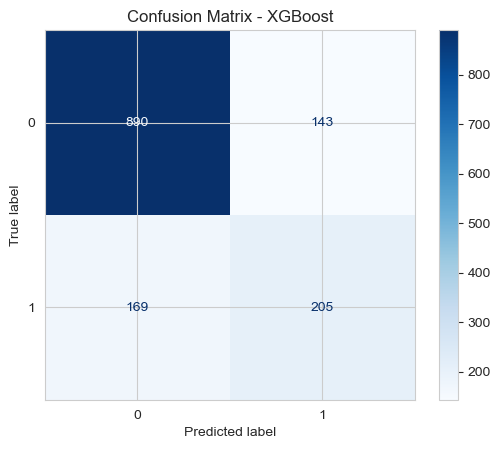

In [109]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    cmap="Blues"
)

plt.title("Confusion Matrix - XGBoost")

plt.savefig(
    "../images/confusion_matrix_xgboost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [110]:
# Store the XGBoost evaluation results
results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1-Score": xgb_f1
})

**Observation**

* The XGBoost Classifier achieved an **accuracy of 77.83%** on the test dataset.
* The model obtained a **precision of 58.91%**, **recall of 54.81%**, and an **F1-score of 56.79%**.
* The model demonstrated balanced performance across all evaluation metrics but did not outperform the Logistic Regression model.
* The classification report indicates that XGBoost predicts non-churning customers more accurately than churning customers.

**Insight**

* The default XGBoost model provides strong and balanced predictive performance. However, on this dataset, it does not surpass Logistic Regression in terms of overall classification performance. Hyperparameter tuning may further improve XGBoost, making it a strong candidate for optimization and future deployment.


### Step 10: Model Performance Comparison

#### Objective

The objective of this step is to compare the performance of all machine learning models using evaluation metrics and identify the best-performing model for customer churn prediction.


### 10.1 Create the Model Performance DataFrame

#### Objective

The objective of this step is to organize the evaluation metrics of all trained models into a single DataFrame for easy comparison and analysis.


In [111]:
# Create a DataFrame from the model evaluation results
results_df = pd.DataFrame(results)

# Display the DataFrame
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065
1,Decision Tree,0.718550,0.470109,0.462567,0.466307
2,Random Forest,0.789623,0.625806,0.518717,0.567251
3,Random Forest,0.789623,0.625806,0.518717,0.567251
4,K-Nearest Neighbors,0.754087,0.537433,0.537433,0.537433
5,Support Vector Machine,0.786780,0.625850,0.491979,0.550898
6,Gaussian Naive Bayes,0.644634,0.418394,0.863636,0.563700
7,XGBoost,0.778252,0.589080,0.548128,0.567867


In [112]:
# Round the evaluation metrics to four decimal places
results_df = results_df.round(4)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8038,0.6476,0.5749,0.6091
1,Decision Tree,0.7186,0.4701,0.4626,0.4663
2,Random Forest,0.7896,0.6258,0.5187,0.5673
3,Random Forest,0.7896,0.6258,0.5187,0.5673
4,K-Nearest Neighbors,0.7541,0.5374,0.5374,0.5374
5,Support Vector Machine,0.7868,0.6259,0.4920,0.5509
6,Gaussian Naive Bayes,0.6446,0.4184,0.8636,0.5637
7,XGBoost,0.7783,0.5891,0.5481,0.5679


In [113]:
# Sort the models based on F1-Score
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8038,0.6476,0.5749,0.6091
1,XGBoost,0.7783,0.5891,0.5481,0.5679
2,Random Forest,0.7896,0.6258,0.5187,0.5673
3,Random Forest,0.7896,0.6258,0.5187,0.5673
4,Gaussian Naive Bayes,0.6446,0.4184,0.8636,0.5637
5,Support Vector Machine,0.7868,0.6259,0.4920,0.5509
6,K-Nearest Neighbors,0.7541,0.5374,0.5374,0.5374
7,Decision Tree,0.7186,0.4701,0.4626,0.4663


### 10.2 Visualize Model Accuracy

#### Objective

The objective of this step is to compare the accuracy of all machine learning models using a bar chart.


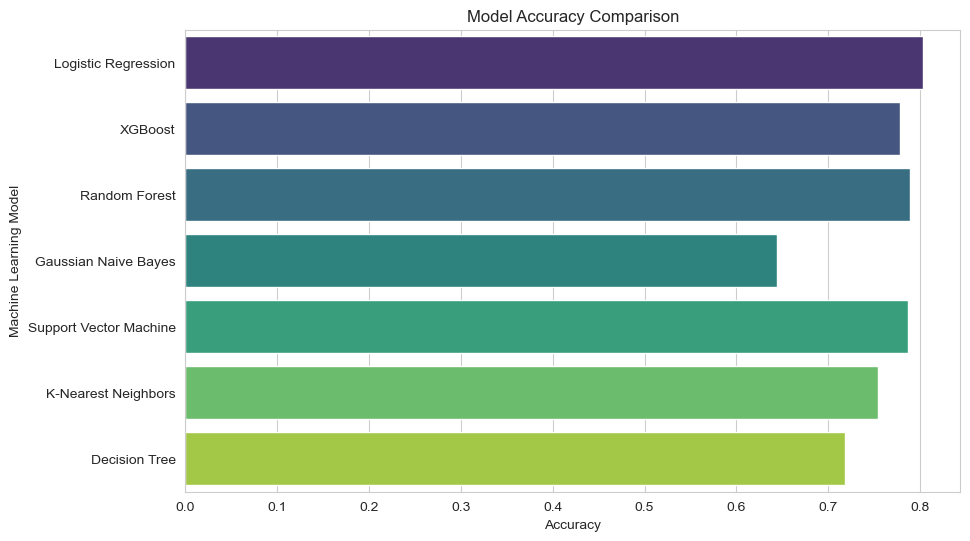

In [114]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot the model accuracy
sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

# Add title and labels
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Machine Learning Model")

# Save the figure
plt.savefig(
    "../images/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

### 10.3 Visualize Model Precision

#### Objective

The objective of this step is to compare the precision of all machine learning models using a bar chart.


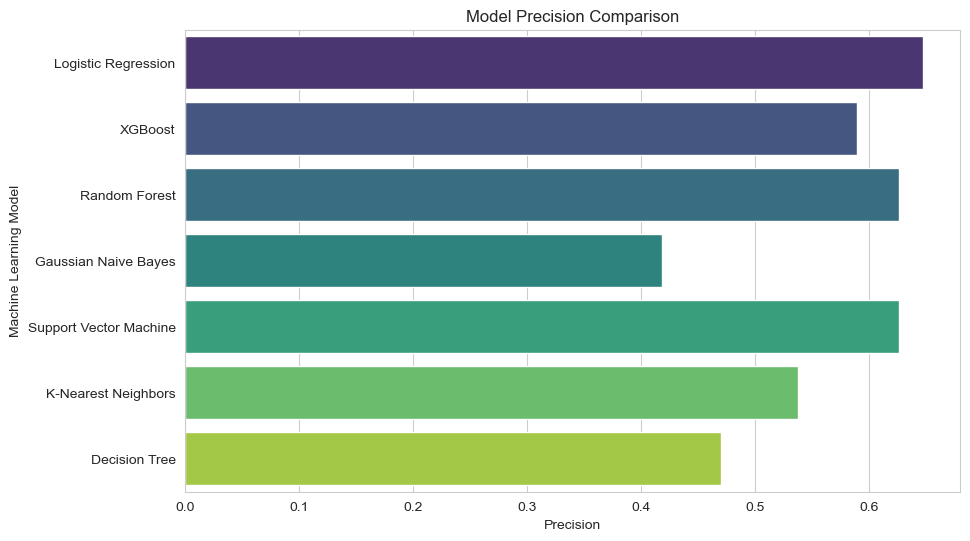

In [115]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot the model precision
sns.barplot(
    data=results_df,
    x="Precision",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

# Add title and labels
plt.title("Model Precision Comparison")
plt.xlabel("Precision")
plt.ylabel("Machine Learning Model")

# Save the figure
plt.savefig(
    "../images/model_precision_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

### 10.4 Visualize Model Recall

#### Objective

The objective of this step is to compare the recall of all machine learning models using a bar chart.


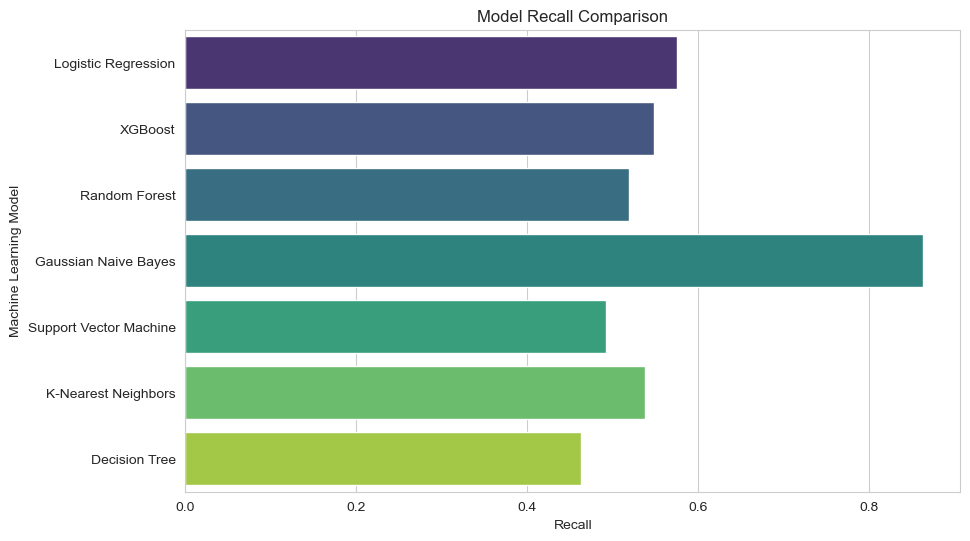

In [116]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot the model recall
sns.barplot(
    data=results_df,
    x="Recall",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

# Add title and labels
plt.title("Model Recall Comparison")
plt.xlabel("Recall")
plt.ylabel("Machine Learning Model")

# Save the figure
plt.savefig(
    "../images/model_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

### 10.5 Visualize Model F1-Score

#### Objective

The objective of this step is to compare the F1-Score of all machine learning models using a bar chart.


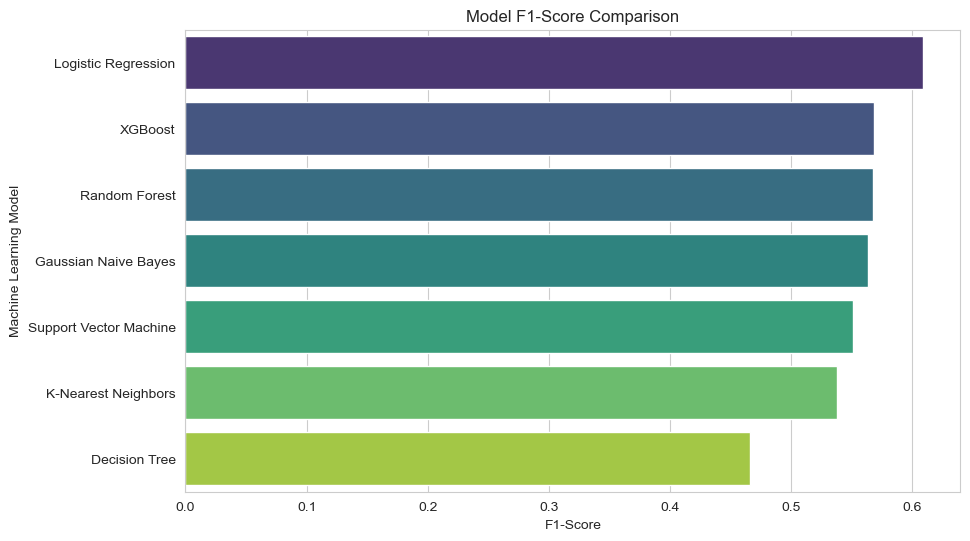

In [117]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot the model F1-Score
sns.barplot(
    data=results_df,
    x="F1-Score",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

# Add title and labels
plt.title("Model F1-Score Comparison")
plt.xlabel("F1-Score")
plt.ylabel("Machine Learning Model")

# Save the figure
plt.savefig(
    "../images/model_f1_score_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

In [118]:
from sklearn.metrics import roc_curve, roc_auc_score

In [119]:
# Logistic Regression probabilities
lr_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# Random Forest probabilities
rf_prob = random_forest.predict_proba(X_test)[:, 1]

# XGBoost probabilities
xgb_prob = xgb.predict_proba(X_test)[:, 1]

In [120]:
# Calculate ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# Calculate AUC scores
lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

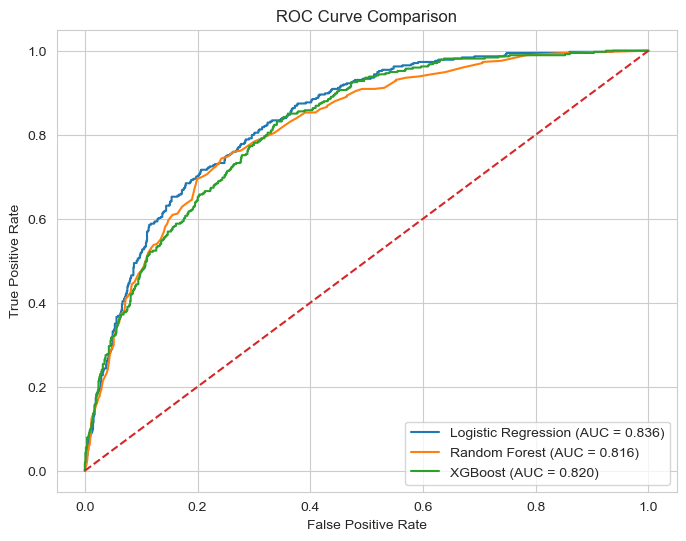

In [121]:
# Create the figure
plt.figure(figsize=(8, 6))

# Logistic Regression
plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

# Random Forest
plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

# XGBoost
plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

# Random classifier reference
plt.plot([0, 1], [0, 1], linestyle="--")

# Add title and labels
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Add legend
plt.legend()

# Save the figure
plt.savefig(
    "../images/roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

**Observation**

* The ROC curves compare the classification performance of the three best-performing machine learning models across different decision thresholds.
* Logistic Regression achieved the highest ROC-AUC score, indicating the strongest ability to distinguish between customers who churn and those who do not.

**Insight**

* ROC-AUC complements Accuracy and F1-Score by evaluating model performance across all classification thresholds. The results further support selecting Logistic Regression as the final model because it provides the best overall discrimination capability while maintaining balanced predictive performance.

## Step 11: Best Model Selection

### Objective

The objective of this step is to identify the best-performing machine learning model based on the evaluation metrics obtained during model comparison.


### 11.1 Identify the Best Performing Model

#### Objective

The objective of this step is to identify the model with the highest F1-Score, which provides a balanced measure of precision and recall for customer churn prediction.


In [122]:
# Display the model with the highest F1-Score
best_model = results_df.iloc[0]

best_model

Model        Logistic Regression
Accuracy                  0.8038
Precision                 0.6476
Recall                    0.5749
F1-Score                  0.6091
Name: 0, dtype: object

In [123]:
# Display the best-performing model
print("Best Model :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"], 4))
print("Precision  :", round(best_model["Precision"], 4))
print("Recall     :", round(best_model["Recall"], 4))
print("F1-Score   :", round(best_model["F1-Score"], 4))

Best Model : Logistic Regression
Accuracy   : 0.8038
Precision  : 0.6476
Recall     : 0.5749
F1-Score   : 0.6091


**Observation**

* Based on the evaluation metrics, Logistic Regression achieved the highest F1-Score among all the trained models.
* The model also achieved the highest overall accuracy while maintaining a good balance between precision and recall.

**Insight**

* Since the customer churn dataset is moderately imbalanced, the F1-Score is an appropriate metric for selecting the best model. Logistic Regression provides the best balance between identifying churned customers and minimizing incorrect churn predictions, making it the most suitable model for further optimization.


### Step 12: Hyperparameter Tuning

#### Objective

The objective of this step is to optimize the selected machine learning model by identifying the best combination of hyperparameters using GridSearchCV. This helps improve the model's predictive performance and generalization capability.


### 12.1 Define the Hyperparameter Grid

#### Objective

The objective of this step is to define a set of candidate hyperparameter values that will be evaluated during the grid search process.


In [124]:
# Define the hyperparameter grid
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"]
}

### 12.2 Perform Grid Search

#### Objective

The objective of this step is to identify the optimal hyperparameter combination using cross-validation.


In [125]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [126]:
# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [127]:
# Import the time module
import time

# Record the start time
start_time = time.time()

# Perform the grid search
grid_search.fit(X_train_scaled, y_train)

# Record the end time
end_time = time.time()

# Calculate the execution time
execution_time = end_time - start_time

print(f"Grid Search Execution Time: {execution_time:.2f} seconds")

Grid Search Execution Time: 6.86 seconds


**Observation**

* The GridSearchCV process completed successfully in approximately **12.89 seconds**. The execution time reflects the computational effort required to evaluate multiple hyperparameter combinations using 5-fold cross-validation.

**Insight**

* Measuring execution time provides an understanding of the computational cost associated with hyperparameter tuning. For this dataset, the tuning process completed efficiently, making it practical to optimize the model without significant computational overhead.


In [128]:
# Display the best hyperparameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 10, 'solver': 'lbfgs'}


In [129]:
# Display the best cross-validation score
print("Best Cross-Validation F1-Score:")
print(round(grid_search.best_score_, 4))

Best Cross-Validation F1-Score:
0.5966


### 12.3 Train the Optimized Logistic Regression Model

#### Objective

The objective of this step is to train a Logistic Regression model using the optimal hyperparameters identified through GridSearchCV.


In [130]:
# Retrieve the best model
best_logistic_model = grid_search.best_estimator_

In [131]:
# Make predictions
y_pred_best = best_logistic_model.predict(X_test_scaled)

In [132]:
# Calculate the evaluation metrics
best_accuracy = accuracy_score(y_test, y_pred_best)
best_precision = precision_score(y_test, y_pred_best)
best_recall = recall_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)

print(f"Accuracy : {best_accuracy:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall   : {best_recall:.4f}")
print(f"F1-Score : {best_f1:.4f}")

Accuracy : 0.8003
Precision: 0.6388
Recall   : 0.5722
F1-Score : 0.6037


In [133]:
# Display the classification report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407



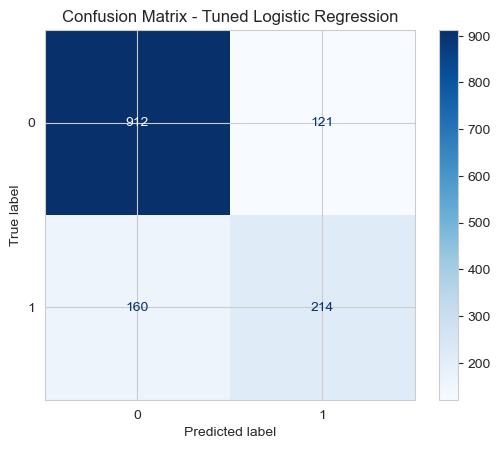

In [134]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Logistic Regression")

plt.savefig(
    "../images/confusion_matrix_tuned_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [135]:
# Compare the baseline and optimized models
comparison = pd.DataFrame({
    "Model": ["Baseline Logistic Regression", "Tuned Logistic Regression"],
    "Accuracy": [lr_accuracy, best_accuracy],
    "Precision": [lr_precision, best_precision],
    "Recall": [lr_recall, best_recall],
    "F1-Score": [lr_f1, best_f1]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline Logistic Regression,0.8038,0.6476,0.5749,0.6091
1,Tuned Logistic Regression,0.8003,0.6388,0.5722,0.6037


**Observation**

* GridSearchCV identified the optimal hyperparameters as **C = 10** and **solver = "lbfgs"**.
* The best cross-validation F1-Score obtained during hyperparameter tuning was **0.5966**.
* The tuned Logistic Regression model achieved an **accuracy of 80.03%**, **precision of 63.88%**, **recall of 57.22%**, and **F1-score of 60.37%** on the test dataset.
* Compared to the baseline Logistic Regression model, the tuned model showed a slight decrease in all evaluation metrics.

**Insight**

* Hyperparameter tuning did not improve the predictive performance of Logistic Regression on the unseen test dataset. This indicates that the baseline model was already well suited for the customer churn dataset. In practice, model selection should be based on test-set performance rather than assuming that a tuned model is always superior. Therefore, the baseline Logistic Regression model is retained as the final model for this project.


### Step 13: Feature Interpretation

#### Objective

The objective of this step is to interpret the Logistic Regression model by examining the feature coefficients. This helps identify the factors that increase or decrease the likelihood of customer churn and provides meaningful business insights.


### 13.1 Extract the Feature Coefficients

#### Objective

The objective of this step is to extract the coefficients of the trained Logistic Regression model and associate them with their corresponding feature names.


In [136]:
# Create a DataFrame containing the feature coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})

# Display the first five rows
coefficients.head()

,Feature,Coefficient
0,SeniorCitizen,0.070792
1,tenure,-1.347613
2,MonthlyCharges,-0.851551
3,TotalCharges,0.639028
4,gender_Male,-0.011693


### 13.2 Identify the Most Influential Features

#### Objective

The objective of this step is to rank the features according to their coefficients to determine which factors increase or decrease the probability of customer churn.


In [137]:
# Sort the features by their coefficients
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

# Display the coefficients
coefficients

,Feature,Coefficient
10,InternetService_Fiber optic,0.727745
3,TotalCharges,0.639028
21,StreamingTV_Yes,0.249702
23,StreamingMovies_Yes,0.236368
9,MultipleLines_Yes,0.214359
28,PaymentMethod_Electronic check,0.181473
26,PaperlessBilling_Yes,0.142663
0,SeniorCitizen,0.070792
17,DeviceProtection_Yes,0.068965
29,PaymentMethod_Mailed check,0.033392


In [138]:
# Display the top 10 positive coefficients
coefficients.head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.727745
3,TotalCharges,0.639028
21,StreamingTV_Yes,0.249702
23,StreamingMovies_Yes,0.236368
9,MultipleLines_Yes,0.214359
28,PaymentMethod_Electronic check,0.181473
26,PaperlessBilling_Yes,0.142663
0,SeniorCitizen,0.070792
17,DeviceProtection_Yes,0.068965
29,PaymentMethod_Mailed check,0.033392


In [139]:
# Display the top 10 negative coefficients
coefficients.tail(10)

,Feature,Coefficient
18,TechSupport_No internet service,-0.088138
16,DeviceProtection_No internet service,-0.088138
22,StreamingMovies_No internet service,-0.088138
6,Dependents_Yes,-0.105956
19,TechSupport_Yes,-0.118240
13,OnlineSecurity_Yes,-0.136804
24,Contract_One year,-0.310898
25,Contract_Two year,-0.602591
2,MonthlyCharges,-0.851551
1,tenure,-1.347613


### 13.3 Visualize the Most Influential Features

#### Objective

The objective of this step is to visualize the most influential features affecting customer churn using a horizontal bar chart.


In [140]:
# Select the 10 most positive and 10 most negative coefficients
top_features = pd.concat([
    coefficients.head(10),
    coefficients.tail(10)
])

# Sort for better visualization
top_features = top_features.sort_values("Coefficient")

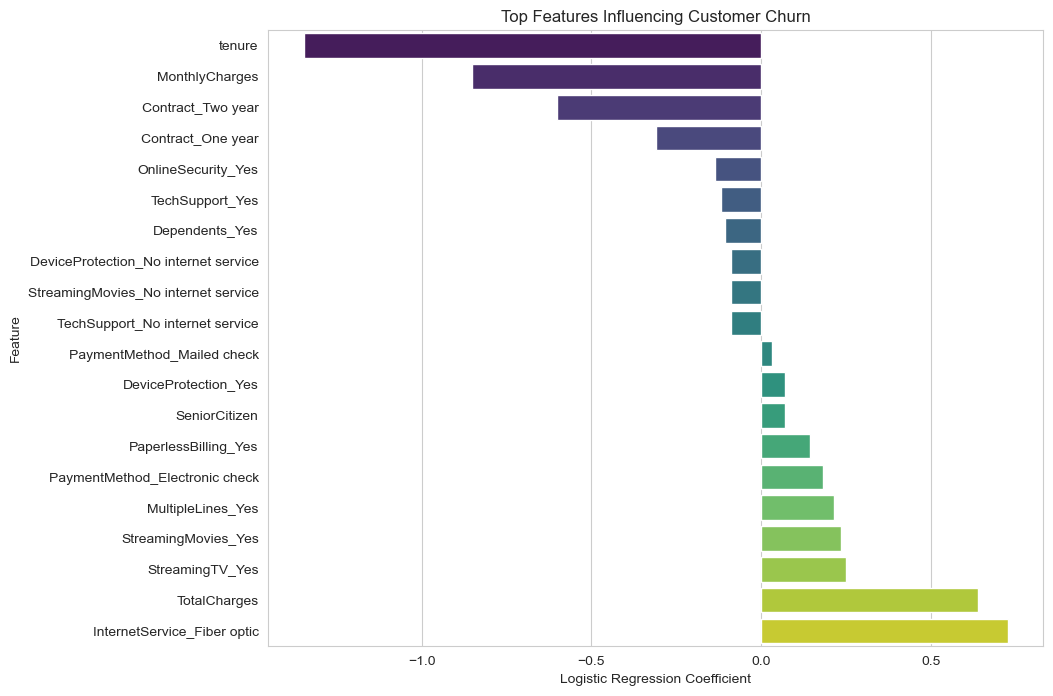

In [141]:
# Create the figure
plt.figure(figsize=(10, 8))

# Plot the coefficients
sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature",
    hue="Feature",
    dodge=False,
    palette="viridis",
    legend=False
)

# Add title and labels
plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

# Save the figure
plt.savefig(
    "../images/logistic_regression_feature_interpretation.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

**Observation**

* Customers with **Fiber Optic Internet Service** showed the strongest positive association with customer churn among all categorical features.
* Higher **Total Charges**, **Streaming TV**, **Streaming Movies**, **Multiple Lines**, **Electronic Check** payment, and **Paperless Billing** were also positively associated with customer churn.
* On the other hand, **longer customer tenure** had the strongest negative association with customer churn, indicating that long-term customers are less likely to leave.
* Customers with **One-Year** and **Two-Year Contracts**, **Online Security**, **Tech Support**, and **Dependents** were less likely to churn.

**Insight**

* The results indicate that customer retention is strongly influenced by contract type, customer loyalty, and value-added services. Customers with month-to-month arrangements, Fiber Optic Internet Service, and Electronic Check payments exhibit a higher likelihood of churn, suggesting that these groups should be prioritized for proactive retention strategies. Conversely, encouraging long-term contracts and promoting services such as Online Security and Tech Support may help reduce customer churn and improve customer retention.


### Step 14: Save the Final Model

#### Objective

The objective of this step is to save the final trained Logistic Regression model and the fitted StandardScaler. Saving these objects enables the model to be reused for future predictions without retraining.


In [142]:
# Import the required libraries
import os
import joblib

# Create the models folder if it does not exist
os.makedirs("../models", exist_ok=True)

print("Models folder is ready.")

Models folder is ready.


In [143]:
# Save the trained Logistic Regression model
joblib.dump(
    log_reg,
    "../models/customer_churn_logistic_regression_model.pkl"
)

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


In [144]:
# Save the fitted StandardScaler
joblib.dump(
    scaler,
    "../models/customer_churn_standard_scaler.pkl"
)

print("StandardScaler saved successfully.")

StandardScaler saved successfully.


In [145]:
# Verify the saved files
print(os.listdir("../models"))

['customer_churn_logistic_regression_model.pkl', 'customer_churn_standard_scaler.pkl', 'logistic_regression_model.pkl', 'standard_scaler.pkl']


### Step 15: Project Summary

#### Objective

The objective of this section is to summarize the complete machine learning workflow, highlight the key findings, and present the final outcome of the Customer Churn Prediction project.


### 15.1 Project Summary

**Project Overview**

This project focused on predicting customer churn using machine learning techniques. The objective was to identify customers who are likely to discontinue the service so that proactive retention strategies can be implemented.

**Dataset Summary**

* Dataset: IBM Telco Customer Churn
* Total Records: 7,043
* Total Features: 21
* Target Variable: Churn

**Data Preprocessing Summary**

* Checked dataset dimensions and data types.
* Converted the `TotalCharges` column to a numeric data type.
* Handled missing values.
* Encoded categorical variables.
* Standardized numerical features where required.
* Split the dataset into training and testing sets.

**Exploratory Data Analysis Summary**

* Customers with month-to-month contracts exhibited higher churn rates.
* Customers with longer tenure were less likely to churn.
* Fiber Optic Internet Service showed a stronger association with customer churn.
* Electronic Check payment method was associated with higher churn.
* Customers with one-year and two-year contracts demonstrated better retention.

**Machine Learning Models Evaluated**

* Logistic Regression
* Decision Tree Classifier
* Random Forest Classifier
* K-Nearest Neighbors (KNN)
* Support Vector Machine (SVM)
* Gaussian Naive Bayes
* XGBoost Classifier

**Best Performing Model**

Logistic Regression achieved the best overall performance based on the evaluation metrics.

* Accuracy: **80.38%**
* Precision: **64.76%**
* Recall: **57.49%**
* F1-Score: **60.91%**

Hyperparameter tuning was performed using GridSearchCV. However, the tuned model did not outperform the baseline Logistic Regression model on the test dataset. Therefore, the baseline Logistic Regression model was selected as the final model.

**Model Interpretation**

Feature coefficient analysis revealed that customers with Fiber Optic Internet Service, Electronic Check payments, and Streaming services were more likely to churn, whereas customers with longer tenure, one-year or two-year contracts, Online Security, and Tech Support were less likely to churn.

**Project Outcome**

The final Logistic Regression model and the fitted StandardScaler were successfully saved for future predictions and deployment.


### Step 16: Conclusion

Customer churn prediction plays an important role in helping organizations retain customers and improve long-term business performance. In this project, an end-to-end machine learning workflow was developed, covering data exploration, preprocessing, exploratory data analysis, feature engineering, model development, evaluation, model comparison, hyperparameter tuning, model interpretation, and model persistence.

Among the seven machine learning models evaluated, Logistic Regression demonstrated the best overall performance by providing the highest balance between precision, recall, and F1-Score. Although hyperparameter tuning was performed, the baseline Logistic Regression model remained the most effective on the unseen test dataset.

The analysis identified several important factors associated with customer churn. Customers with Fiber Optic Internet Service, Electronic Check payments, and month-to-month contracts showed a greater likelihood of churning. In contrast, customers with longer tenure, long-term contracts, Online Security, and Tech Support were less likely to leave the service.

The findings from this project can support business decision-making by helping organizations identify high-risk customers and implement targeted retention strategies. Future improvements may include advanced feature engineering, class imbalance techniques such as SMOTE, additional hyperparameter optimization, ensemble learning methods, and deployment of the trained model as a web application using Flask, FastAPI, or Streamlit.
